In [1]:
import json
import numpy as np
import pandas as pd
import os
from tqdm.auto import tqdm
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
type_of_questions = {
    "commonsensqa": "Common Sense",
    "strategyqa": "Common Sense",
    "coin_flip": "Symbolic",
    "last_letters": "Symbolic",
    "object_tracking": "Other",
    "bigbench_date": "Other",
    # all others, Arithmetic
    "addsub": "Arithmetic",
    "gsm8k": "Arithmetic",
    "singleeq": "Arithmetic",
    "aqua": "Arithmetic",
    "svamp": "Arithmetic",
    "multiarith": "Arithmetic",
}

In [3]:
benchmarks = os.listdir("probabilities/system1")

In [4]:
datasets = dict()
for benchmark in benchmarks:
    with open(os.path.join("probabilities/system1", benchmark, "merged.json")) as f:
        sys1_data = json.load(f)

    with open(os.path.join("probabilities/system2", benchmark, "merged.json")) as f:
        sys2_data = json.load(f)

    assert len(sys1_data) == len(sys2_data)
    datasets[benchmark] = {"sys1": sys1_data, "sys2": sys2_data}

In [5]:
def filter_end_of_sentences(tokens_probs):
    filtered_tokens_probs = [
        (token, prob) for token, prob in tokens_probs if token != "<|eot_id|>"
    ]
    return filtered_tokens_probs

In [6]:
def get_sentence_prob_multi(token_probs):
    probs = [prob for token, prob in token_probs]
    log_probs = np.log(probs)
    return np.sum(log_probs) / len(log_probs)


def get_sentence_prob_mean(token_probs):
    probs = [prob for token, prob in token_probs]
    return np.mean(probs)

In [7]:
datasets_lists = []
system_types = []
ability_lists = []
data_probs_sum_log = []
data_probs_mean_token_prob = []

for dataset in datasets.keys():
    sys1_data = datasets[dataset]["sys1"]
    sys2_data = datasets[dataset]["sys2"]

    for sys1_datapoint, sys2_datapoint in zip(sys1_data, sys2_data):
        sys1_tokens_probs = filter_end_of_sentences(sys1_datapoint)
        sys2_tokens_probs = filter_end_of_sentences(sys2_datapoint)

        data_probs_sum_log.append(get_sentence_prob_multi(sys1_tokens_probs))
        data_probs_sum_log.append(get_sentence_prob_multi(sys2_tokens_probs))

        data_probs_mean_token_prob.append(get_sentence_prob_mean(sys1_tokens_probs))
        data_probs_mean_token_prob.append(get_sentence_prob_mean(sys2_tokens_probs))

        system_types.append("sys1")
        system_types.append("sys2")

        datasets_lists.append(dataset)
        datasets_lists.append(dataset)

        ability_lists.append(type_of_questions[dataset])
        ability_lists.append(type_of_questions[dataset])


df = pd.DataFrame(
    {
        "dataset": datasets_lists,
        "system": system_types,
        "sum_log_probs": data_probs_sum_log,
        "mean_token_prob": data_probs_mean_token_prob,
        "ability": ability_lists,
    }
)

In [8]:
from scipy.stats import ttest_rel

/var/folders/s6/_dcfmqnx4mxbhf22rbww8kwc0000gp/T/ipykernel_21139/2205569037.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  sns.violinplot(
/var/folders/s6/_dcfmqnx4mxbhf22rbww8kwc0000gp/T/ipykernel_21139/2205569037.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")


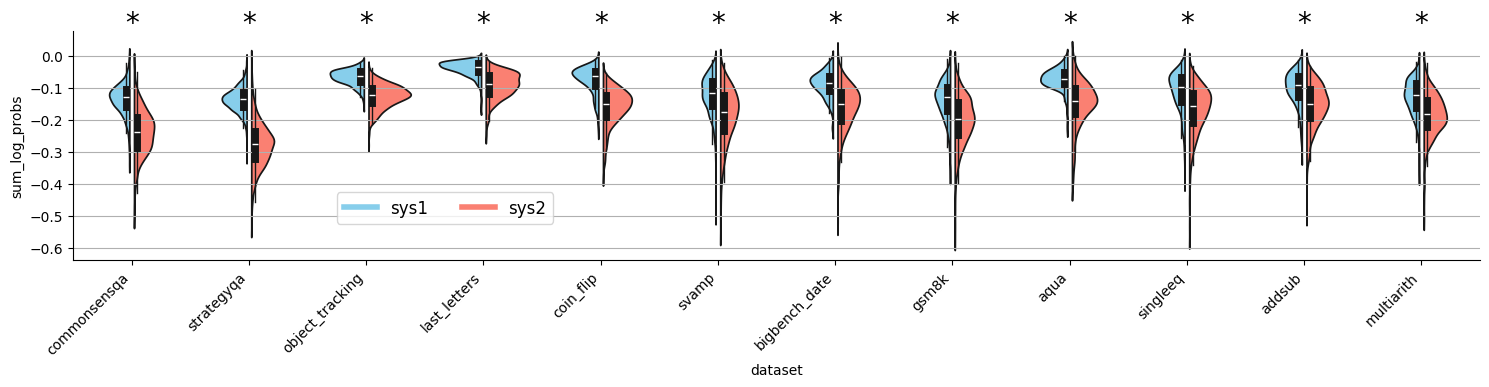

In [9]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 4))
sns.violinplot(
    x="dataset",
    y="sum_log_probs",
    hue="system",
    data=df,
    inner="box",
    split=True,
    gap=0.1,
    # common_norm=True,
    ax=ax,
    inner_kws=dict(
        box_width=5,
        whis_width=1,
    ),
    color="skyblue",
    # palette=[".4", ".7"],
)
colors = ["skyblue", "salmon"]

# put the xtick labels with a rotation of 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgb

for ind, violin in enumerate(ax.findobj(PolyCollection)):
    if ind % 2 != 0:
        rgb = to_rgb(colors[1])
    else:
        rgb = to_rgb(colors[0])
    violin.set_facecolor(rgb)

handles, labels = ax.get_legend_handles_labels()
# handles are salmon and skyblue
handles = [
    plt.Line2D([0], [0], color=colors[0], lw=4),
    plt.Line2D([0], [0], color=colors[1], lw=4),
]
ax.grid(axis="y")
ax.get_legend().remove()
sns.despine()

# on top of each of the xticks, check the difference between two systems using ttest_rel and if significant (< 0.05), put a star on top
for i, dataset in enumerate(df["dataset"].unique()):
    sys1_data = df[(df["dataset"] == dataset) & (df["system"] == "sys1")][
        "sum_log_probs"
    ]
    sys2_data = df[(df["dataset"] == dataset) & (df["system"] == "sys2")][
        "sum_log_probs"
    ]
    t, p = ttest_rel(sys1_data, sys2_data)
    if p < 0.05:
        ax.text(i, 0.1, "*", fontsize=20, ha="center", va="center", color="black")

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.3, 0.4),
    loc="lower center",
    ncol=2,
    fontsize="large",
)

# save the figure
plt.tight_layout()
plt.savefig("sum_log_probs_violinplot.png", dpi=900, bbox_inches="tight")

/var/folders/s6/_dcfmqnx4mxbhf22rbww8kwc0000gp/T/ipykernel_21139/3722433560.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  sns.violinplot(


T-test results for ability Common Sense : t(3510) = 106.860, p = 0.000
T-test results for ability Other : t(1118) = 38.021, p = 0.000
T-test results for ability Symbolic : t(999) = 42.537, p = 0.000
T-test results for ability Arithmetic : t(4075) = 54.539, p = 0.000


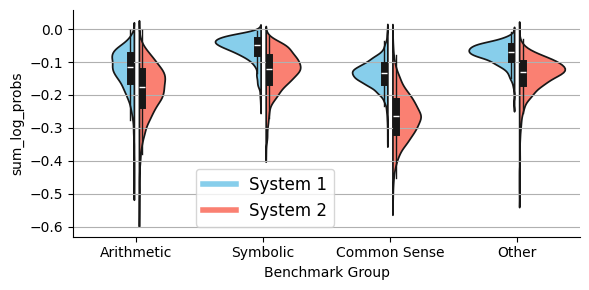

In [10]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))
sns.violinplot(
    x="ability",
    y="sum_log_probs",
    hue="system",
    data=df,
    inner="box",
    split=True,
    gap=0.1,
    # common_norm=True,
    ax=ax,
    inner_kws=dict(
        box_width=5,
        whis_width=1,
    ),
    color="skyblue",
    # palette=[".4", ".7"],
    order=["Arithmetic", "Symbolic", "Common Sense", "Other"],
)
colors = ["skyblue", "salmon"]

# put the xtick labels with a rotation of 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0, horizontalalignment="right")
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgb

ax.set_xlabel("Benchmark Group")

for ind, violin in enumerate(ax.findobj(PolyCollection)):
    if ind % 2 != 0:
        rgb = to_rgb(colors[1])
    else:
        rgb = to_rgb(colors[0])
    violin.set_facecolor(rgb)

handles, labels = ax.get_legend_handles_labels()
# handles are salmon and skyblue
handles = [
    plt.Line2D([0], [0], color=colors[0], lw=4),
    plt.Line2D([0], [0], color=colors[1], lw=4),
]
ax.grid(axis="y")
ax.get_legend().remove()
sns.despine()

# on top of each of the xticks, check the difference between two systems using ttest_rel and if significant (< 0.05), put a star on top
for i, ability in enumerate(df["ability"].unique()):
    sys1_data = df[(df["ability"] == ability) & (df["system"] == "sys1")][
        "sum_log_probs"
    ]
    sys2_data = df[(df["ability"] == ability) & (df["system"] == "sys2")][
        "sum_log_probs"
    ]
    t, p = ttest_rel(sys1_data, sys2_data)
    print(
        "T-test results for ability",
        ability,
        ":",
        f"t({len(sys1_data)-1}) = {t:.3f}, p = {p:.3f}",
    )

fig.legend(
    handles,
    ["System 1", "System 2"],
    bbox_to_anchor=(0.45, 0.2),
    loc="lower center",
    ncol=1,
    fontsize="large",
)

# save the figure
plt.tight_layout()
plt.savefig("sum_log_probs_violinplot.png", dpi=900, bbox_inches="tight")